In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/Fraud Detection Dataset (1).csv")
print(df.shape)
df.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
df.columns.tolist()
list(df)

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [5]:
df=df.dropna()

In [6]:
missing_percent = df.isnull().mean()*100

print(missing_percent)

Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 688


### Task 1: Column-wise Duplicate Count

In [8]:
# Count repeated values in each column
duplicate_counts = {}

for col in df.columns:
    duplicate_counts[col] = df[col].duplicated().sum()

duplicate_counts = pd.Series(duplicate_counts).sort_values(ascending=False)
print("Duplicate values by column:")
print(duplicate_counts)

Duplicate values by column:
Fraudulent                          39581
Device_Used                         39579
Transaction_Type                    39578
Payment_Method                      39578
Previous_Fraudulent_Transactions    39578
Location                            39575
Number_of_Transactions_Last_24H     39569
Time_of_Transaction                 39559
Account_Age                         39464
User_ID                             35583
Transaction_Amount                   2667
Transaction_ID                        787
dtype: int64


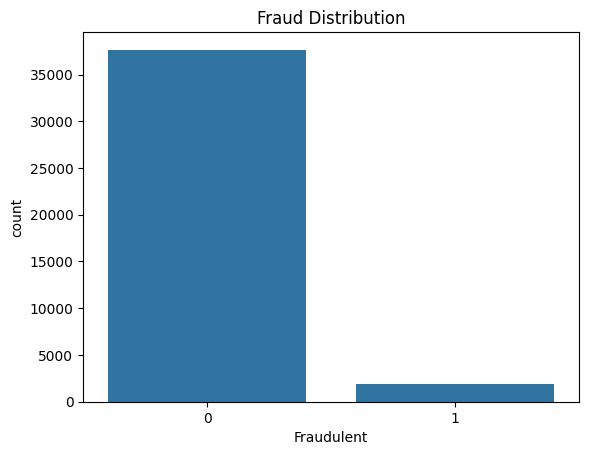

In [9]:
sns.countplot(x="Fraudulent", data=df)

plt.title("Fraud Distribution")

plt.show()

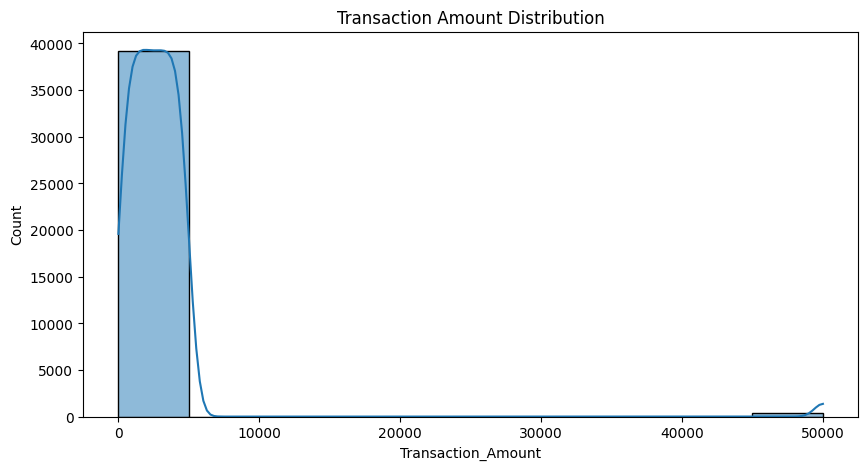

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Transaction_Amount"],
    bins=10,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

### Task 2: Payment Method vs Fraudulent

Fraudulent          0     1    All
Payment_Method                    
Credit Card      9009   460   9469
Debit Card       9167   456   9623
Invalid Method   1174    56   1230
Net Banking      9029   474   9503
UPI              9272   486   9758
All             37651  1932  39583


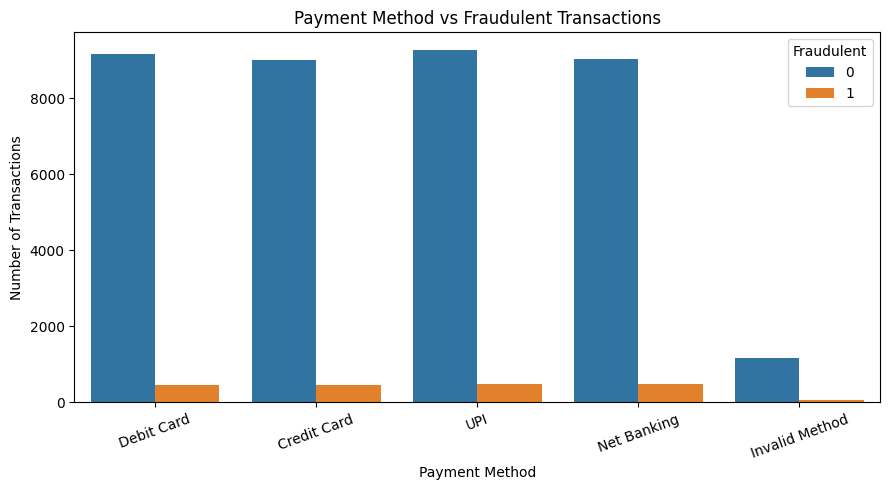

In [11]:
# Compare fraud cases across payment methods
payment_fraud = pd.crosstab(
    df["Payment_Method"],
    df["Fraudulent"],
    margins=True
)

print(payment_fraud)

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Fraudulent"
)
plt.title("Payment Method vs Fraudulent Transactions")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

<Axes: >

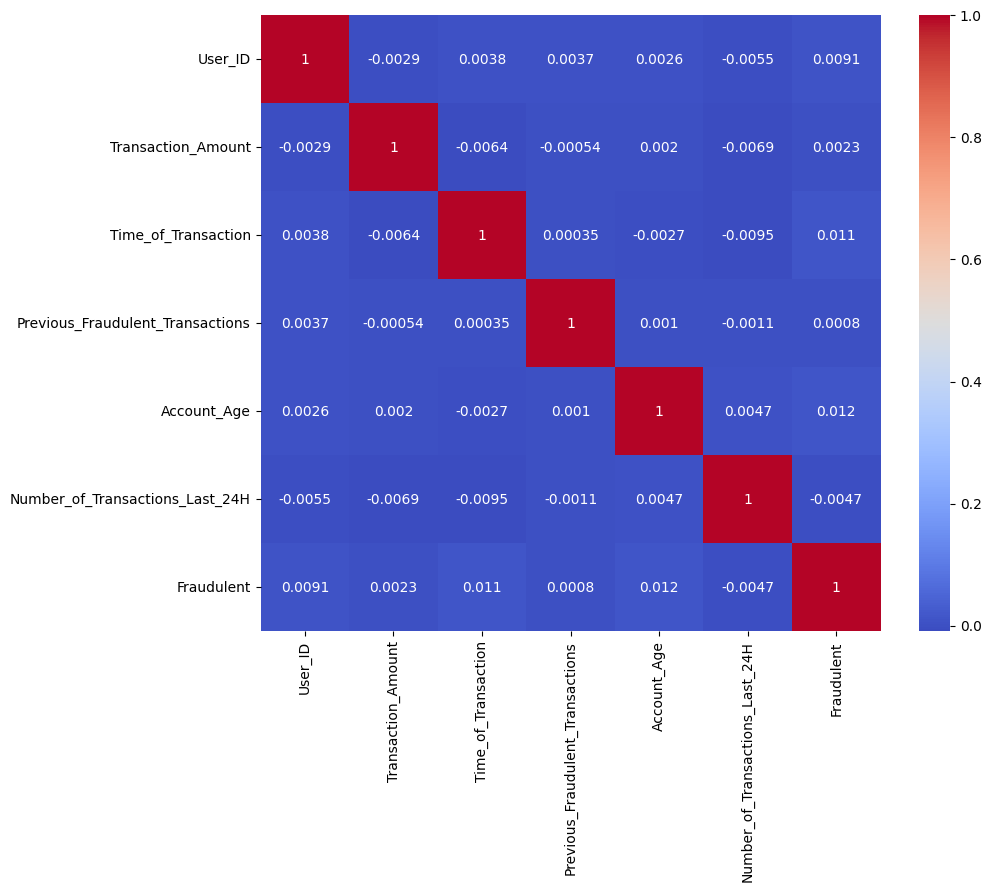

In [12]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm"

)

# Outlier

Text(0.5, 1.0, 'Transaction Amount Boxplot')

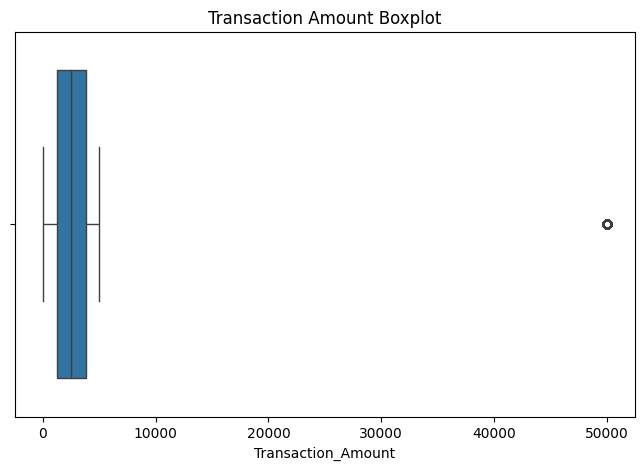

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")

In [14]:
Q1 = df["Transaction_Amount"].quantile(0.25)

Q3 = df["Transaction_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR


outliers = df[
    (df["Transaction_Amount"] < lower) |
    (df["Transaction_Amount"] > upper)
]

#Lower_outlier= df[df["Transaction_Amount"] < lower]

#Lower_outlier.head()

#upper_outlier= df[df["Transaction_Amount"] < upper]

#upper_outlier.head()
#upper_outlier.shape
#Lower_outlier.shape
print(outliers.shape)
#outliers.head()

(416, 12)


### Task 2: Find Outliers in Time_of_Transaction

Number of time outliers: 0
Empty DataFrame
Columns: [Transaction_ID, Time_of_Transaction, Fraudulent]
Index: []


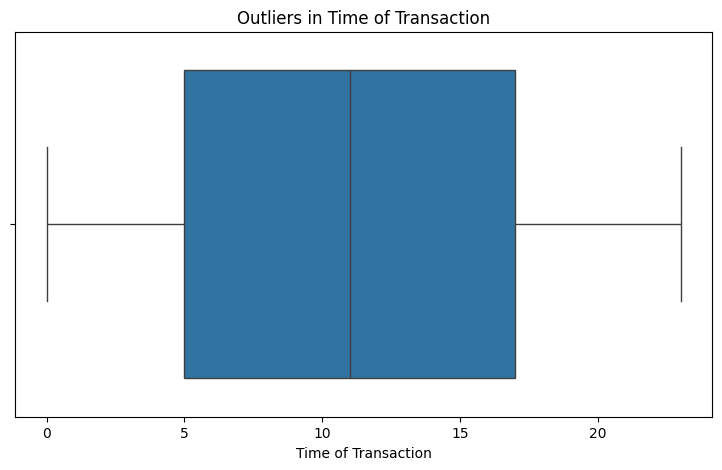

In [15]:
# Check for unusual transaction times using the IQR method
Q1_time = df["Time_of_Transaction"].quantile(0.25)
Q3_time = df["Time_of_Transaction"].quantile(0.75)
IQR_time = Q3_time - Q1_time

lower_time = Q1_time - 1.5 * IQR_time
upper_time = Q3_time + 1.5 * IQR_time

time_outliers = df[
    (df["Time_of_Transaction"] < lower_time) |
    (df["Time_of_Transaction"] > upper_time)
]

print("Number of time outliers:", len(time_outliers))
print(time_outliers[["Transaction_ID", "Time_of_Transaction", "Fraudulent"]].head())

plt.figure(figsize=(9, 5))
sns.boxplot(x=df["Time_of_Transaction"])
plt.title("Outliers in Time of Transaction")
plt.xlabel("Time of Transaction")
plt.show()

### Task 3: Identify Common and Uncommon Values

In [16]:
# Look at the most and least frequent values in a few important columns
check_columns = ["Payment_Method", "Transaction_Type", "Device_Used", "Location"]

for col in check_columns:
    counts = df[col].value_counts()
    print(f"\n--- {col} ---")
    print("Most common values:")
    print(counts.head(5))
    print("Least common values:")
    print(counts.tail(5))


--- Payment_Method ---
Most common values:
Payment_Method
UPI               9758
Debit Card        9623
Net Banking       9503
Credit Card       9469
Invalid Method    1230
Name: count, dtype: int64
Least common values:
Payment_Method
UPI               9758
Debit Card        9623
Net Banking       9503
Credit Card       9469
Invalid Method    1230
Name: count, dtype: int64

--- Transaction_Type ---
Most common values:
Transaction_Type
Bank Transfer      8012
Bill Payment       7963
ATM Withdrawal     7890
POS Payment        7871
Online Purchase    7847
Name: count, dtype: int64
Least common values:
Transaction_Type
Bank Transfer      8012
Bill Payment       7963
ATM Withdrawal     7890
POS Payment        7871
Online Purchase    7847
Name: count, dtype: int64

--- Device_Used ---
Most common values:
Device_Used
Desktop           12835
Tablet            12777
Mobile            12734
Unknown Device     1237
Name: count, dtype: int64
Least common values:
Device_Used
Desktop           1283

In [17]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]


In [18]:
from sklearn.preprocessing import StandardScaler

X = df[features]
#X=X.dropna()
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)

In [20]:
df["Cluster"] = labels
#df.head()
df["Cluster"].value_counts()

,count
Cluster,
0,39167
1,408
-1,8


### Task 4: Identify Anomalies with -1 (Different Feature Set)

In [21]:
# Use a second set of features for anomaly detection
features_2 = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Number_of_Transactions_Last_24H",
    "Previous_Fraudulent_Transactions"
]

X2 = df[features_2]
scaler_2 = StandardScaler()
X2_scaled = scaler_2.fit_transform(X2)

dbscan_2 = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels_2 = dbscan_2.fit_predict(X2_scaled)
df["Cluster_2"] = labels_2

print("Cluster counts for the second feature set:")
print(df["Cluster_2"].value_counts().sort_index())

suspicious_2 = df[df["Cluster_2"] == -1]

print("\nNumber of anomalies:", len(suspicious_2))
print(suspicious_2[[
    "Transaction_ID",
    "Transaction_Amount",
    "Time_of_Transaction",
    "Number_of_Transactions_Last_24H",
    "Previous_Fraudulent_Transactions",
    "Fraudulent"
]].head(10))

Cluster counts for the second feature set:
Cluster_2
-1        9
 0    39167
 1      407
Name: count, dtype: int64

Number of anomalies: 9
      Transaction_ID  Transaction_Amount  Time_of_Transaction  \
317             T318             49997.8                  0.0   
1553           T1554             49997.8                  0.0   
2615           T2616             49997.8                  0.0   
8146           T8147             49997.8                 17.0   
13045         T13046             49997.8                 14.0   
15990         T15991             49997.8                 19.0   
27030         T27031             49997.8                  9.0   
39032         T39033             49997.8                  8.0   
45593         T45594             49997.8                 23.0   

       Number_of_Transactions_Last_24H  Previous_Fraudulent_Transactions  \
317                                 14                                 4   
1553                                11                    

In [22]:
suspicious = df[df["Cluster"] == -1]

print(suspicious.head())

      Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
317             T318     4681             49997.8     Bill Payment   
8146           T8147     1640             49997.8     Bill Payment   
15441         T15442     4030             49997.8    Bank Transfer   
19824         T19825     2206             49997.8  Online Purchase   
22058         T22059     3612             49997.8    Bank Transfer   

       Time_of_Transaction Device_Used     Location  \
317                    0.0      Mobile      Houston   
8146                  17.0      Tablet  Los Angeles   
15441                 20.0     Desktop      Seattle   
19824                 14.0      Mobile        Miami   
22058                 20.0      Tablet     New York   

       Previous_Fraudulent_Transactions  Account_Age  \
317                                   4            4   
8146                                  4            7   
15441                                 0            5   
19824                   

### Task 5: Create Graphs for Anomalies

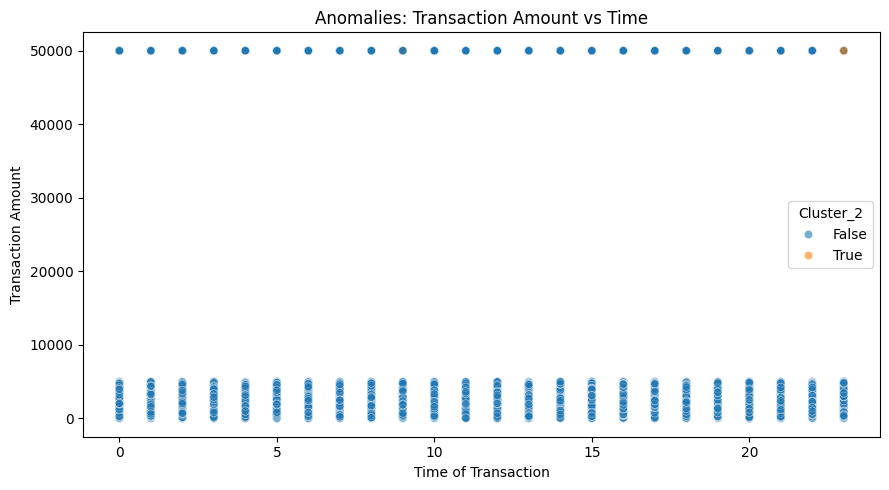

In [23]:
# Visualize the anomalous transaction amounts
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Time_of_Transaction",
    y="Transaction_Amount",
    hue=(df["Cluster_2"] == -1),
    alpha=0.6
)
plt.title("Anomalies: Transaction Amount vs Time")
plt.xlabel("Time of Transaction")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

### Task 5: Cluster Graph (any two attributes)

In [24]:
x_attr = "Transaction_Amount"
y_attr = "Previous_Fraudulent_Transactions"


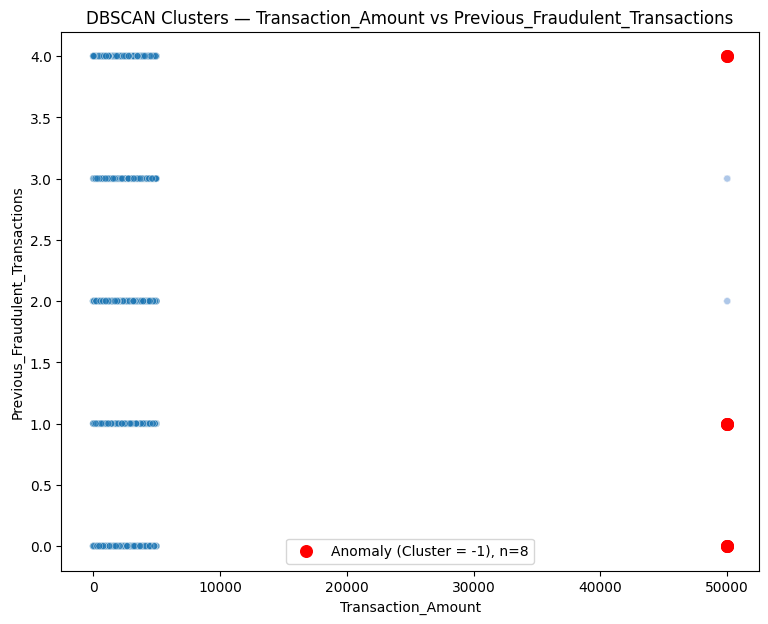

In [25]:
non_noise = df[df["Cluster"] != -1]
noise = df[df["Cluster"] == -1]

sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_sample,
    x=x_attr, y=y_attr,
    hue="Cluster",
    palette="tab20",
    alpha=0.6, s=25,
    legend=False
)

plt.scatter(
    noise[x_attr], noise[y_attr],
    c="red", marker="o", s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title(f"DBSCAN Clusters — {x_attr} vs {y_attr}")
plt.legend()
plt.show()


### Final observation
The DBSCAN approach treats records labelled **-1** as observations that do not belong to a dense cluster. These records can be reviewed as potentially unusual transactions, but they should not automatically be treated as confirmed fraud.